# Create synthetic data from ogden fits then give to abaqus to fit

Found scale values that:
 - Kept diff in uniform half of plot to within 0.04MPa and 10%
 - Kept diff between experimental and compression to within 0.05MPa and 10%
 - Kept behaviour in uniaxial, biaxial, and shear stable
 - For incompressible, Ogden coeffs found here exactly match ogden coeffs returned by Abaqus
 ---
 - There are many ways that the elastic can reach its breaking point at ~4.5 strain and 2 MPa
 - 90% of tensile strain in model is below 1.0 so not worried that investigated tensile curves don't meet above failure point cos it still tells us about low strain variation importance, which is most relevant as 90% of tensile strain is below 1.0?
 ---
 - The Ogden fits here are identical to those output by abaqus to ~ 5 or 6 decimal places
    - $\nu$ = 0.45 did not change the coefficients in abaqus

# Study 7

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from phd_helpers.experiments import get_instron_data
from scipy.optimize import least_squares


# get data

e50_path = Path('../../../Experimental/LabData/materialsTesting/cylinders/elastico/20260427')

F0 = 0.5 # (N) initial seating load
dN = 10 # (mm) total displacement after preload applied

L0 = 20
A0 = np.pi*(5**2) # mm^2

orientations = ['Vertical', 'Horizontal']

e50 = []
for orient in orientations:
    glob = f'**/{orient[0]}.*/*.csv'
    for path in e50_path.glob(glob):
        sample_repeat = path.with_suffix('').name # e.g. 1_3 (sample 1 repeat 3)
        s, r = sample_repeat.split('_')

        data_raw = get_instron_data(path, False)
        data_raw['force'] *= 1e3 # convert from kN to N
        data = data_raw[data_raw['force'] >= F0] # get data after initial load
        data['displacement'] -= data['displacement'].min() # reset displacement
        data = data[data['displacement'] <= dN] # clip excess

        data['strain'] = data['displacement'] / L0
        data['stress'] = data['force'] / A0 # MPa

        data['orient'] = np.full(len(data), orient)
        data['sample'] = np.full(len(data), int(s))
        data['repeat'] = np.full(len(data), int(r))

        e50.append(data)
        
df = pd.concat(e50).sort_values(['orient', 'sample', 'repeat', 'time'], ascending=True).reset_index(drop=True)

group_cols = ["orient", "sample", "repeat"]

df_fit = df.copy()

# Zero stress separately for each test curve
df_fit["stress_zeroed"] = (
    df_fit["stress"]
    - df_fit.groupby(group_cols)["stress"].transform("first")
)

# Optional: remove the very beginning if contact/preload effects dominate
#df_fit = df_fit[df_fit["strain"] > 0.005].copy()

# Compression stretch
df_fit["lambda"] = 1.0 - df_fit["strain"]

# Neo-Hookean compression predictor:
# stress = mu * (lambda^-2 - lambda)
df_fit["x"] = df_fit["lambda"]**(-2) - df_fit["lambda"]

# Keep only valid data
df_fit = df_fit.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["stress_zeroed", "x"]
)

In [2]:
# ============================================================
# FUNCTIONS
# ============================================================

def neo_hookean_mu(C10):
    return 2.0 * C10

def neo_hookean_compression_stress(eps, mu):
    lam = 1.0 - eps
    return mu * (lam**-2.0 - lam)

def neo_hookean_tension_stress(eps, mu):
    lam = 1.0 + eps
    return mu * (lam - lam**-2.0)

def scaled_nh_compression_stress(eps, scale, mu):
    return scale * neo_hookean_compression_stress(eps, mu)

def scaled_nh_tension_stress(eps, scale, mu):
    return scale * neo_hookean_tension_stress(eps, mu)

def ogden_P(lam, p):
    P = np.zeros_like(lam, dtype=float)
    for mu, alpha in zip(p[0::2], p[1::2]):
        P += (2.0 * mu / alpha) * (
            lam**(alpha - 1.0)
            - lam**(-alpha / 2.0 - 1.0)
        )
    return P

def initial_guess(N, mu):
    guesses = {
        1: [mu, 2.0],
        2: [0.70 * mu, 2.0, 0.30 * mu, -2.0],
        3: [0.50 * mu, 2.0, 0.30 * mu, -2.0, 0.20 * mu, 6.0],
    }
    return np.array(guesses[N])

def compressibility_terms(mu_initial, N, poisson_ratio):
    if poisson_ratio is None:
        return True, np.inf, [None] * N

    K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
        3.0 * (1.0 - 2.0 * poisson_ratio)
    )

    D = np.zeros(N)
    D[0] = 2.0 / K

    return False, K, D



def compare_ogden_curves_on_non_synthetic_side(
    fit_results,
    synthetic_side,
    eps_c,
    lam_c,
    eps_t,
    lam_t,
    ogden_P,
):
    if len(fit_results) < 2:
        return

    if synthetic_side == "tension":
        side = "compression"
        eps_compare = eps_c
        lam_compare = lam_c
        curves = [-ogden_P(lam_compare, res["params"]) for res in fit_results]
    else:
        side = "tension"
        eps_compare = eps_t
        lam_compare = lam_t
        curves = [ogden_P(lam_compare, res["params"]) for res in fit_results]

    print("\n" + "=" * 70)
    print(f"Ogden curve comparison on non-synthetic side: {side}")

    for i in range(len(fit_results)):
        for j in range(i + 1, len(fit_results)):
            y_i = curves[i]
            y_j = curves[j]

            abs_diff = np.abs(y_i - y_j)
            idx = np.argmax(abs_diff)

            max_abs = abs_diff[idx]
            pct_at_max_abs = 100.0 * max_abs / abs(np.mean((y_i[idx], y_j[idx])))

            print("\n" + "-" * 70)
            print(
                f"Scale {fit_results[i]['scale']:g} vs "
                f"scale {fit_results[j]['scale']:g}"
            )
            print(f"Max absolute difference = {max_abs:.8g}")
            print(f"Percentage difference at max absolute difference = {pct_at_max_abs:.8g}%")
            print(f"  at {side} strain = {eps_compare[idx]:.8g}")
            print(f"  curve 1 stress = {y_i[idx]:.8g}")
            print(f"  curve 2 stress = {y_j[idx]:.8g}")

def compare_synthetic_compression_to_raw_orientation_data(
    fit_results,
    synthetic_side,
    synthetic_scales,
    df_raw,
    ogden_P,
    strain_col="strain",
    stress_col="stress_zeroed",
    orient_col="orient",
    horizontal_label="Horizontal",
    vertical_label="Vertical",
):
    if synthetic_side != "compression" or len(synthetic_scales) != 2:
        return

    high_scale = max(synthetic_scales)
    low_scale = min(synthetic_scales)

    cases = [
        (high_scale, horizontal_label),
        (low_scale, vertical_label),
    ]

    print("\n" + "=" * 70)
    print("Synthetic compression curve vs raw experimental data")

    for scale, orient in cases:
        res = next(r for r in fit_results if r["scale"] == scale)

        g = df_raw[df_raw[orient_col] == orient].copy()
        g = g.dropna(subset=[strain_col, stress_col])

        eps = g[strain_col].to_numpy()
        raw = g[stress_col].to_numpy()

        model = -ogden_P(1.0 - eps, res["params"])

        abs_diff = np.abs(model - raw)
        idx = np.argmax(abs_diff)

        max_abs = abs_diff[idx]
        pct_at_max_abs = 100.0 * max_abs / abs(np.mean((raw[idx], model[idx])))

        print("\n" + "-" * 70)
        print(f"Scale {scale:g} vs {orient} raw data")
        print(f"Max absolute difference = {max_abs:.8g}")
        print(f"Percentage difference at max absolute difference = {pct_at_max_abs:.8g}%")
        print(f"  at compression strain = {eps[idx]:.8g}")
        print(f"  Ogden stress = {model[idx]:.8g}")
        print(f"  raw stress = {raw[idx]:.8g}")
        #print(f'sample', g['sample'].iloc[idx])
        #print(f'repeat', g['repeat'].iloc[idx])



def ogden_simple_shear_stress(gamma, p):
    gamma = np.asarray(gamma, dtype=float)

    l1 = np.sqrt(1.0 + gamma**2 / 4.0) + gamma / 2.0
    l2 = np.sqrt(1.0 + gamma**2 / 4.0) - gamma / 2.0

    tau = np.zeros_like(gamma)

    for mu, alpha in zip(p[0::2], p[1::2]):
        tau += (2.0 * mu / alpha) * (l1**alpha - l2**alpha) / (l1 + l2)

    return tau

def plot_behaviour(
    fit_results,
    mu_NH,
    synthetic_side,
    compression_strain_min,
    compression_strain_max,
    tension_strain_max,
    ogden_P,
    scaled_nh_compression_stress,
    scaled_nh_tension_stress,
    neo_hookean_compression_stress,
    neo_hookean_tension_stress,
    df_raw=None,
    group_cols=None,
    plot_max_comp=0.5,
    plot_max_tens=1.0
):
    eps_c_plot = np.linspace(compression_strain_min, plot_max_comp, 300)
    eps_t_plot = np.linspace(0.0, plot_max_tens, 300)
    gamma_plot = np.linspace(0.0, plot_max_tens, 300)

    lam_c_plot = 1.0 - eps_c_plot
    lam_t_plot = 1.0 + eps_t_plot

    nh_c_plot = neo_hookean_compression_stress(eps_c_plot, mu_NH)
    nh_t_plot = neo_hookean_tension_stress(eps_t_plot, mu_NH)
    nh_s_plot = mu_NH * gamma_plot

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(eps_c_plot, nh_c_plot, linestyle="--", linewidth=2.5, color="black", label="Neo-Hookean compression")
    ax[1].plot(eps_t_plot, nh_t_plot, linestyle="--", linewidth=2.5, color="black", label="Neo-Hookean tension")

    for i, res in enumerate(fit_results):
        scale = res["scale"]
        color = f"C{i}"

        ax[0].plot(
            eps_c_plot,
            -ogden_P(lam_c_plot, res["params"]),
            linewidth=2,
            color=color,
            label=f"Ogden, scale={scale:g}"
        )

        ax[1].plot(
            eps_t_plot,
            ogden_P(lam_t_plot, res["params"]),
            linewidth=2,
            color=color,
            label=f"Ogden, scale={scale:g}"
        )

        if synthetic_side == "tension":
            ax[1].plot(
                eps_t_plot,
                scaled_nh_tension_stress(eps_t_plot, scale, mu_NH),
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                color=color
            )
        else:
            ax[0].plot(
                eps_c_plot,
                scaled_nh_compression_stress(eps_c_plot, scale, mu_NH),
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                color=color
            )

    if df_raw is not None and group_cols is not None:
        for _, g in df_raw.groupby(group_cols):
            ax[0].plot(g["strain"], g["stress_zeroed"], alpha=0.15, linewidth=0.8)

    ax[0].set_title("Compression behaviour")
    ax[1].set_title("Tensile behaviour")

    ax[0].set_xlabel("Engineering compression strain")
    ax[1].set_xlabel("Engineering tensile strain")

    for a in ax:
        a.set_ylabel("Stress")
        a.grid(True)
        a.legend()

    fig.tight_layout()
    plt.show()


def find_curves(
        N_OGDEN, 
        n_points, 
        compression_strain_min, 
        compression_strain_max, 
        tension_strain_max, 
        C10_input, 
        synthetic_side, 
        synthetic_scales,compression_weight,
        tension_weight,
        poisson_ratio,
        plot_max_comp,
        plot_max_tens
    ):
    # ============================================================
    # TARGET DATA
    # ============================================================

    mu_NH = neo_hookean_mu(C10_input)

    eps_c = np.linspace(compression_strain_min, compression_strain_max, n_points)
    eps_t = np.linspace(0.0, tension_strain_max, n_points)

    lam_c = 1.0 - eps_c
    lam_t = 1.0 + eps_t

    print(f"Input Neo-Hookean C10 = {C10_input:.6g}")
    print(f"Input Neo-Hookean mu  = {mu_NH:.6g}")
    print(f"Synthetic side      = {synthetic_side}")

    if synthetic_side == "tension":
        sig_c_base = neo_hookean_compression_stress(eps_c, mu_NH)
        sig_t_base = None
    else:
        sig_c_base = None
        sig_t_base = neo_hookean_tension_stress(eps_t, mu_NH)


    # ============================================================
    # OGDEN FIT
    # ============================================================

    p0 = initial_guess(N_OGDEN, mu_NH)
    lb = np.tile([-20.0 * abs(mu_NH), -20.0], N_OGDEN)
    ub = np.tile([ 20.0 * abs(mu_NH),  20.0], N_OGDEN)

    fit_results = []

    for scale in synthetic_scales:
        if synthetic_side == "tension":
            sig_c = sig_c_base
            sig_t = scaled_nh_tension_stress(eps_t, scale, mu_NH)
            case_label = f"NH compression, scaled NH tension scale={scale:g}"

        else:
            sig_c = scaled_nh_compression_stress(eps_c, scale, mu_NH)
            sig_t = sig_t_base
            case_label = f"scaled NH compression scale={scale:g}, NH tension"

        def resid(p):
            return np.r_[
                compression_weight * (-ogden_P(lam_c, p) - sig_c),
                tension_weight * ( ogden_P(lam_t, p) - sig_t),
                1e-5 * p
            ]

        result = least_squares(
            resid,
            p0,
            bounds=(lb, ub),
            max_nfev=50000,
            xtol=1e-10,
            ftol=1e-10,
            gtol=1e-10
        )

        p = result.x
        mu_terms = p[0::2]
        alpha_terms = p[1::2]
        mu_initial = np.sum(mu_terms)

        incompressible, K, D_terms = compressibility_terms(mu_initial, N_OGDEN, poisson_ratio)

        fit_results.append({
            "scale": scale,
            "label": case_label,
            "params": p,
            "D_terms": D_terms,
            "K": K,
            "mu_initial": mu_initial,
            "sig_c": sig_c,
            "sig_t": sig_t,
        })

        print("\n" + "=" * 70)
        print(case_label)
        print(f"Initial shear modulus sum(mu_i) = {mu_initial:.8g}")

        if not incompressible:
            print(f"K = {K:.8g}")

        print("Ogden parameters:")

        for i in range(N_OGDEN):
            if incompressible:
                print(
                    f"  mu{i+1} = {mu_terms[i]:.8g}, "
                    f"alpha{i+1} = {alpha_terms[i]:.8g}"
                )
            else:
                print(
                    f"  mu{i+1} = {mu_terms[i]:.8g}, "
                    f"alpha{i+1} = {alpha_terms[i]:.8g}, "
                    f"D{i+1} = {D_terms[i]:.8g}"
                )

    compare_ogden_curves_on_non_synthetic_side(
        fit_results=fit_results,
        synthetic_side=synthetic_side,
        eps_c=eps_c,
        lam_c=lam_c,
        eps_t=eps_t,
        lam_t=lam_t,
        ogden_P=ogden_P,
    )
    compare_synthetic_compression_to_raw_orientation_data(
        fit_results=fit_results,
        synthetic_side=synthetic_side,
        synthetic_scales=synthetic_scales,
        df_raw=df_fit,
        ogden_P=ogden_P,
    )

    # ============================================================
    # PLOTTING
    # ============================================================

    plot_behaviour(
        fit_results=fit_results,
        mu_NH=mu_NH,
        synthetic_side=synthetic_side,
        compression_strain_min=compression_strain_min,
        compression_strain_max=compression_strain_max,
        tension_strain_max=tension_strain_max,
        ogden_P=ogden_P,
        scaled_nh_compression_stress=scaled_nh_compression_stress,
        scaled_nh_tension_stress=scaled_nh_tension_stress,
        neo_hookean_compression_stress=neo_hookean_compression_stress,
        neo_hookean_tension_stress=neo_hookean_tension_stress,
        df_raw=df_fit,
        group_cols=group_cols,
        plot_max_comp=plot_max_comp,
        plot_max_tens=plot_max_tens
    )
    return fit_results

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# ----------------------------
# strain energy functions
# ----------------------------

def poly_terms(N, kind="full"):
    if kind == "reduced":
        return [(i, 0) for i in range(1, N + 1)]
    return [(i, n - i) for n in range(1, N + 1) for i in range(n, -1, -1)]


def W_poly(lams, C, terms):
    l1, l2, l3 = lams
    I1 = l1**2 + l2**2 + l3**2
    I2 = l1**2*l2**2 + l2**2*l3**2 + l3**2*l1**2
    return sum(c * (I1 - 3)**i * (I2 - 3)**j for c, (i, j) in zip(C, terms))


def W_ogden(lams, p):
    W = 0.0
    for mu, alpha in zip(p[0::2], p[1::2]):
        W += 2 * mu / alpha**2 * sum(lam**alpha - 1 for lam in lams)
    return W


def W_model(lams, fit):
    if "Ogden" in fit["model"]:
        return W_ogden(lams, fit["params"])
    return W_poly(lams, fit["params"], fit["terms"])


# ----------------------------
# deformation modes
# ----------------------------

def stretches(mode, x):
    x = np.asarray(x, dtype=float)
    lam = 1.0 + x

    if mode == "uniaxial":
        return np.array([lam, lam**-0.5, lam**-0.5])

    if mode == "biaxial":
        return np.array([lam, lam, lam**-2.0])

    if mode == "planar":
        return np.array([lam, np.ones_like(lam), lam**-1.0])

    if mode == "simple_shear":
        g = x
        l1 = np.sqrt(1.0 + g**2 / 4.0) + g / 2.0
        l2 = np.sqrt(1.0 + g**2 / 4.0) - g / 2.0
        return np.array([l1, l2, np.ones_like(g)])


def stress_mode(x, fit, mode, h=1e-6):
    x = np.asarray(x, dtype=float)

    def W_of_x(xv):
        return W_model(stretches(mode, xv), fit)

    return (W_of_x(x + h) - W_of_x(x - h)) / (2 * h)


# ----------------------------
# fitting functions
# ----------------------------

def make_D_terms(mu_initial, N, nu):
    if nu == 0.5:
        return np.zeros(N), np.inf

    K = 2.0 * mu_initial * (1.0 + nu) / (3.0 * (1.0 - 2.0 * nu))
    D = np.zeros(N)
    D[0] = 2.0 / K
    return D, K


def poly_initial_mu(C, terms):
    C10 = C[terms.index((1, 0))] if (1, 0) in terms else 0.0
    C01 = C[terms.index((0, 1))] if (0, 1) in terms else 0.0
    return 2.0 * (C10 + C01)


def fit_polynomial(df, N=2, kind="full", nu=0.5):
    terms = poly_terms(N, kind)
    x = df["strain"].to_numpy()
    y = df["stress"].to_numpy()

    C0 = np.zeros(len(terms))
    if (1, 0) in terms:
        C0[terms.index((1, 0))] = abs(y).max() / 2

    fit = {
        "model": f"{kind.capitalize()} polynomial N={N}",
        "terms": terms,
        "params": C0,
        "N": N,
        "nu": nu,
    }

    def resid(C):
        fit["params"] = C
        return stress_mode(x, fit, "uniaxial") - y

    fit["params"] = least_squares(resid, C0, max_nfev=50000).x
    fit["mu_initial"] = poly_initial_mu(fit["params"], terms)
    fit["D"], fit["K"] = make_D_terms(fit["mu_initial"], N, nu)

    return fit


def fit_reduced_polynomial(df, N=3, nu=0.5):
    return fit_polynomial(df, N=N, kind="reduced", nu=nu)


def fit_full_polynomial(df, N=2, nu=0.5):
    return fit_polynomial(df, N=N, kind="full", nu=nu)


def fit_ogden(df, N=2, nu=0.5):
    x = df["strain"].to_numpy()
    y = df["stress"].to_numpy()

    mu0 = np.sum(((1 + x)**-2 - (1 + x)) * (-y)) / np.sum(((1 + x)**-2 - (1 + x))**2)

    guesses = {
        1: [mu0, 2.0],
        2: [0.7 * mu0, 2.0, 0.3 * mu0, -2.0],
        3: [0.5 * mu0, 2.0, 0.3 * mu0, -2.0, 0.2 * mu0, 6.0],
    }

    p0 = np.array(guesses[N])
    lb = np.tile([-20 * abs(mu0), -20], N)
    ub = np.tile([ 20 * abs(mu0),  20], N)

    fit = {
        "model": f"Ogden N={N}",
        "params": p0,
        "N": N,
        "nu": nu,
    }

    def resid(p):
        fit["params"] = p
        return stress_mode(x, fit, "uniaxial") - y

    fit["params"] = least_squares(resid, p0, bounds=(lb, ub), max_nfev=50000).x
    fit["mu_initial"] = np.sum(fit["params"][0::2])
    fit["D"], fit["K"] = make_D_terms(fit["mu_initial"], N, nu)

    return fit


# ----------------------------
# coefficient printing
# ----------------------------

def print_fit(fit):
    print("\n" + "=" * 60)
    print(fit["model"], f"  (nu = {fit['nu']:.8g})")

    if "Ogden" in fit["model"]:
        for i, (mu, alpha) in enumerate(zip(fit["params"][0::2], fit["params"][1::2]), 1):
            print(f"\tmu{i} = {mu:.8g}, alpha{i} = {alpha:.8g}")
    else:
        for c, (i, j) in zip(fit["params"], fit["terms"]):
            print(f"\tC{i}{j} = {c:.8g}")

    #print(f"\tK = {fit['K']:.8g}")
    for i, d in enumerate(fit["D"], 1):
        print(f"\tD{i} = {d:.8g}")


# ----------------------------
# plotting
# ----------------------------

def plot_hyperelastic_fits(
    fits,
    uniaxial_range=(-0.5, 1.5),
    biaxial_range=(-0.5, 1.5),
    planar_range=(-0.5, 1.5),
    shear_range=(-0.5, 1.5),
    n=300,
    df=None,
):
    modes = [
        ("uniaxial", uniaxial_range, "Uniaxial", "Engineering strain"),
        ("biaxial", biaxial_range, "Biaxial", "Engineering strain"),
        ("planar", planar_range, "Planar (pure shear)", "Engineering strain"),
        ("simple_shear", shear_range, "Simple shear", "Shear strain γ"),
    ]

    fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
    ax = ax.flatten()

    for a, (mode, xrng, title, xlabel) in zip(ax, modes):
        x = np.linspace(*xrng, n)

        if mode == "uniaxial" and df is not None:
            a.plot(df["strain"], df["stress"], "k.", markersize=0.5, alpha=0.5, label="Experimental")

        for fit in fits:
            a.plot(x, stress_mode(x, fit, mode), linewidth=2, label=fit["model"])

        a.set_title(title)
        a.set_xlabel(xlabel)
        a.set_ylabel("Nominal stress" if mode != "simple_shear" else "Shear stress")
        a.grid(True)
        a.legend()
        a.axhline(0, color='black', linewidth=0.8)
        a.axvline(0, color='black', linewidth=0.8)

    fig.tight_layout()
    plt.show()






def fit_results_to_plot_fits(fit_results, model_prefix="Ogden"):
    return [
        {
            "model": f"{model_prefix}, scale={res['scale']}",
            "params": res["params"],
            "D": res.get("D_terms", None),
            "K": res.get("K", None),
            "mu_initial": res.get("mu_initial", None),
        }
        for res in fit_results
    ]

df_exp_plot = df_fit[["strain", "stress_zeroed"]].copy()
df_exp_plot = df_exp_plot.rename(columns={"stress_zeroed": "stress"})

# df_fit uses positive compression
df_exp_plot["strain"] = -np.abs(df_exp_plot["strain"])
df_exp_plot["stress"] = -np.abs(df_exp_plot["stress"])


# COMPRESSION

Input Neo-Hookean C10 = 0.0975
Input Neo-Hookean mu  = 0.195
Synthetic side      = compression

scaled NH compression scale=1.17, NH tension
Initial shear modulus sum(mu_i) = 0.20842815
K = 2.0148055
Ogden parameters:
  mu1 = 0.18101116, alpha1 = 2.0431867, D1 = 0.99265166
  mu2 = 0.027416993, alpha2 = -0.83162853, D2 = 0

scaled NH compression scale=0.84, NH tension
Initial shear modulus sum(mu_i) = 0.18248663
K = 1.7640374
Ogden parameters:
  mu1 = 0.20839655, alpha1 = 1.9617261, D1 = 1.1337628
  mu2 = -0.025909924, alpha2 = -0.82933317, D2 = 0

Ogden curve comparison on non-synthetic side: tension

----------------------------------------------------------------------
Scale 1.17 vs scale 0.84
Max absolute difference = 0.013989278
Percentage difference at max absolute difference = 6.4563789%
  at tension strain = 0.53453453
  curve 1 stress = 0.22366838
  curve 2 stress = 0.2096791

Synthetic compression curve vs raw experimental data

------------------------------------------------

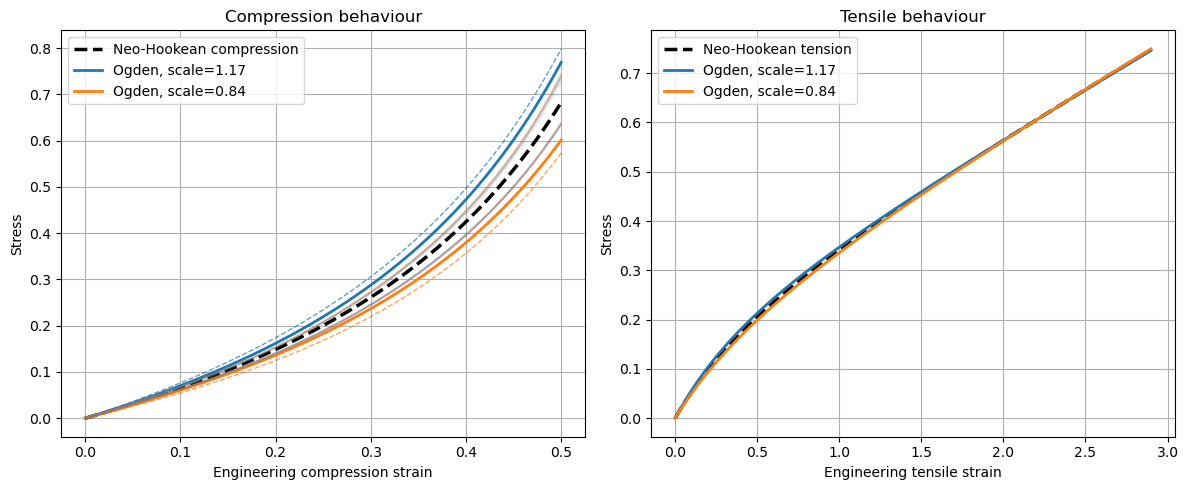

In [23]:

# ============================================================
# USER SETTINGS
# ============================================================

N_OGDEN = 2

n_points = 1000
compression_strain_min = 0.00
compression_strain_max = 0.95
tension_strain_max = 6.0


C10_input = 0.0975
synthetic_side = "compression"     # "compression" or "tension"
synthetic_scales = [1.17, 0.84]

compression_weight = 1.0
tension_weight = 5.0

poisson_ratio = 0.45                 # None for incompressible

fit_results_comp = find_curves(
        N_OGDEN, 
        n_points, 
        compression_strain_min, 
        compression_strain_max=compression_strain_max, 
        tension_strain_max=tension_strain_max, 
        C10_input=C10_input, 
        synthetic_side=synthetic_side, 
        synthetic_scales=synthetic_scales,
        compression_weight=compression_weight,
        tension_weight=tension_weight,
        poisson_ratio=poisson_ratio,
        plot_max_comp=0.5,
        plot_max_tens=2.9
    )

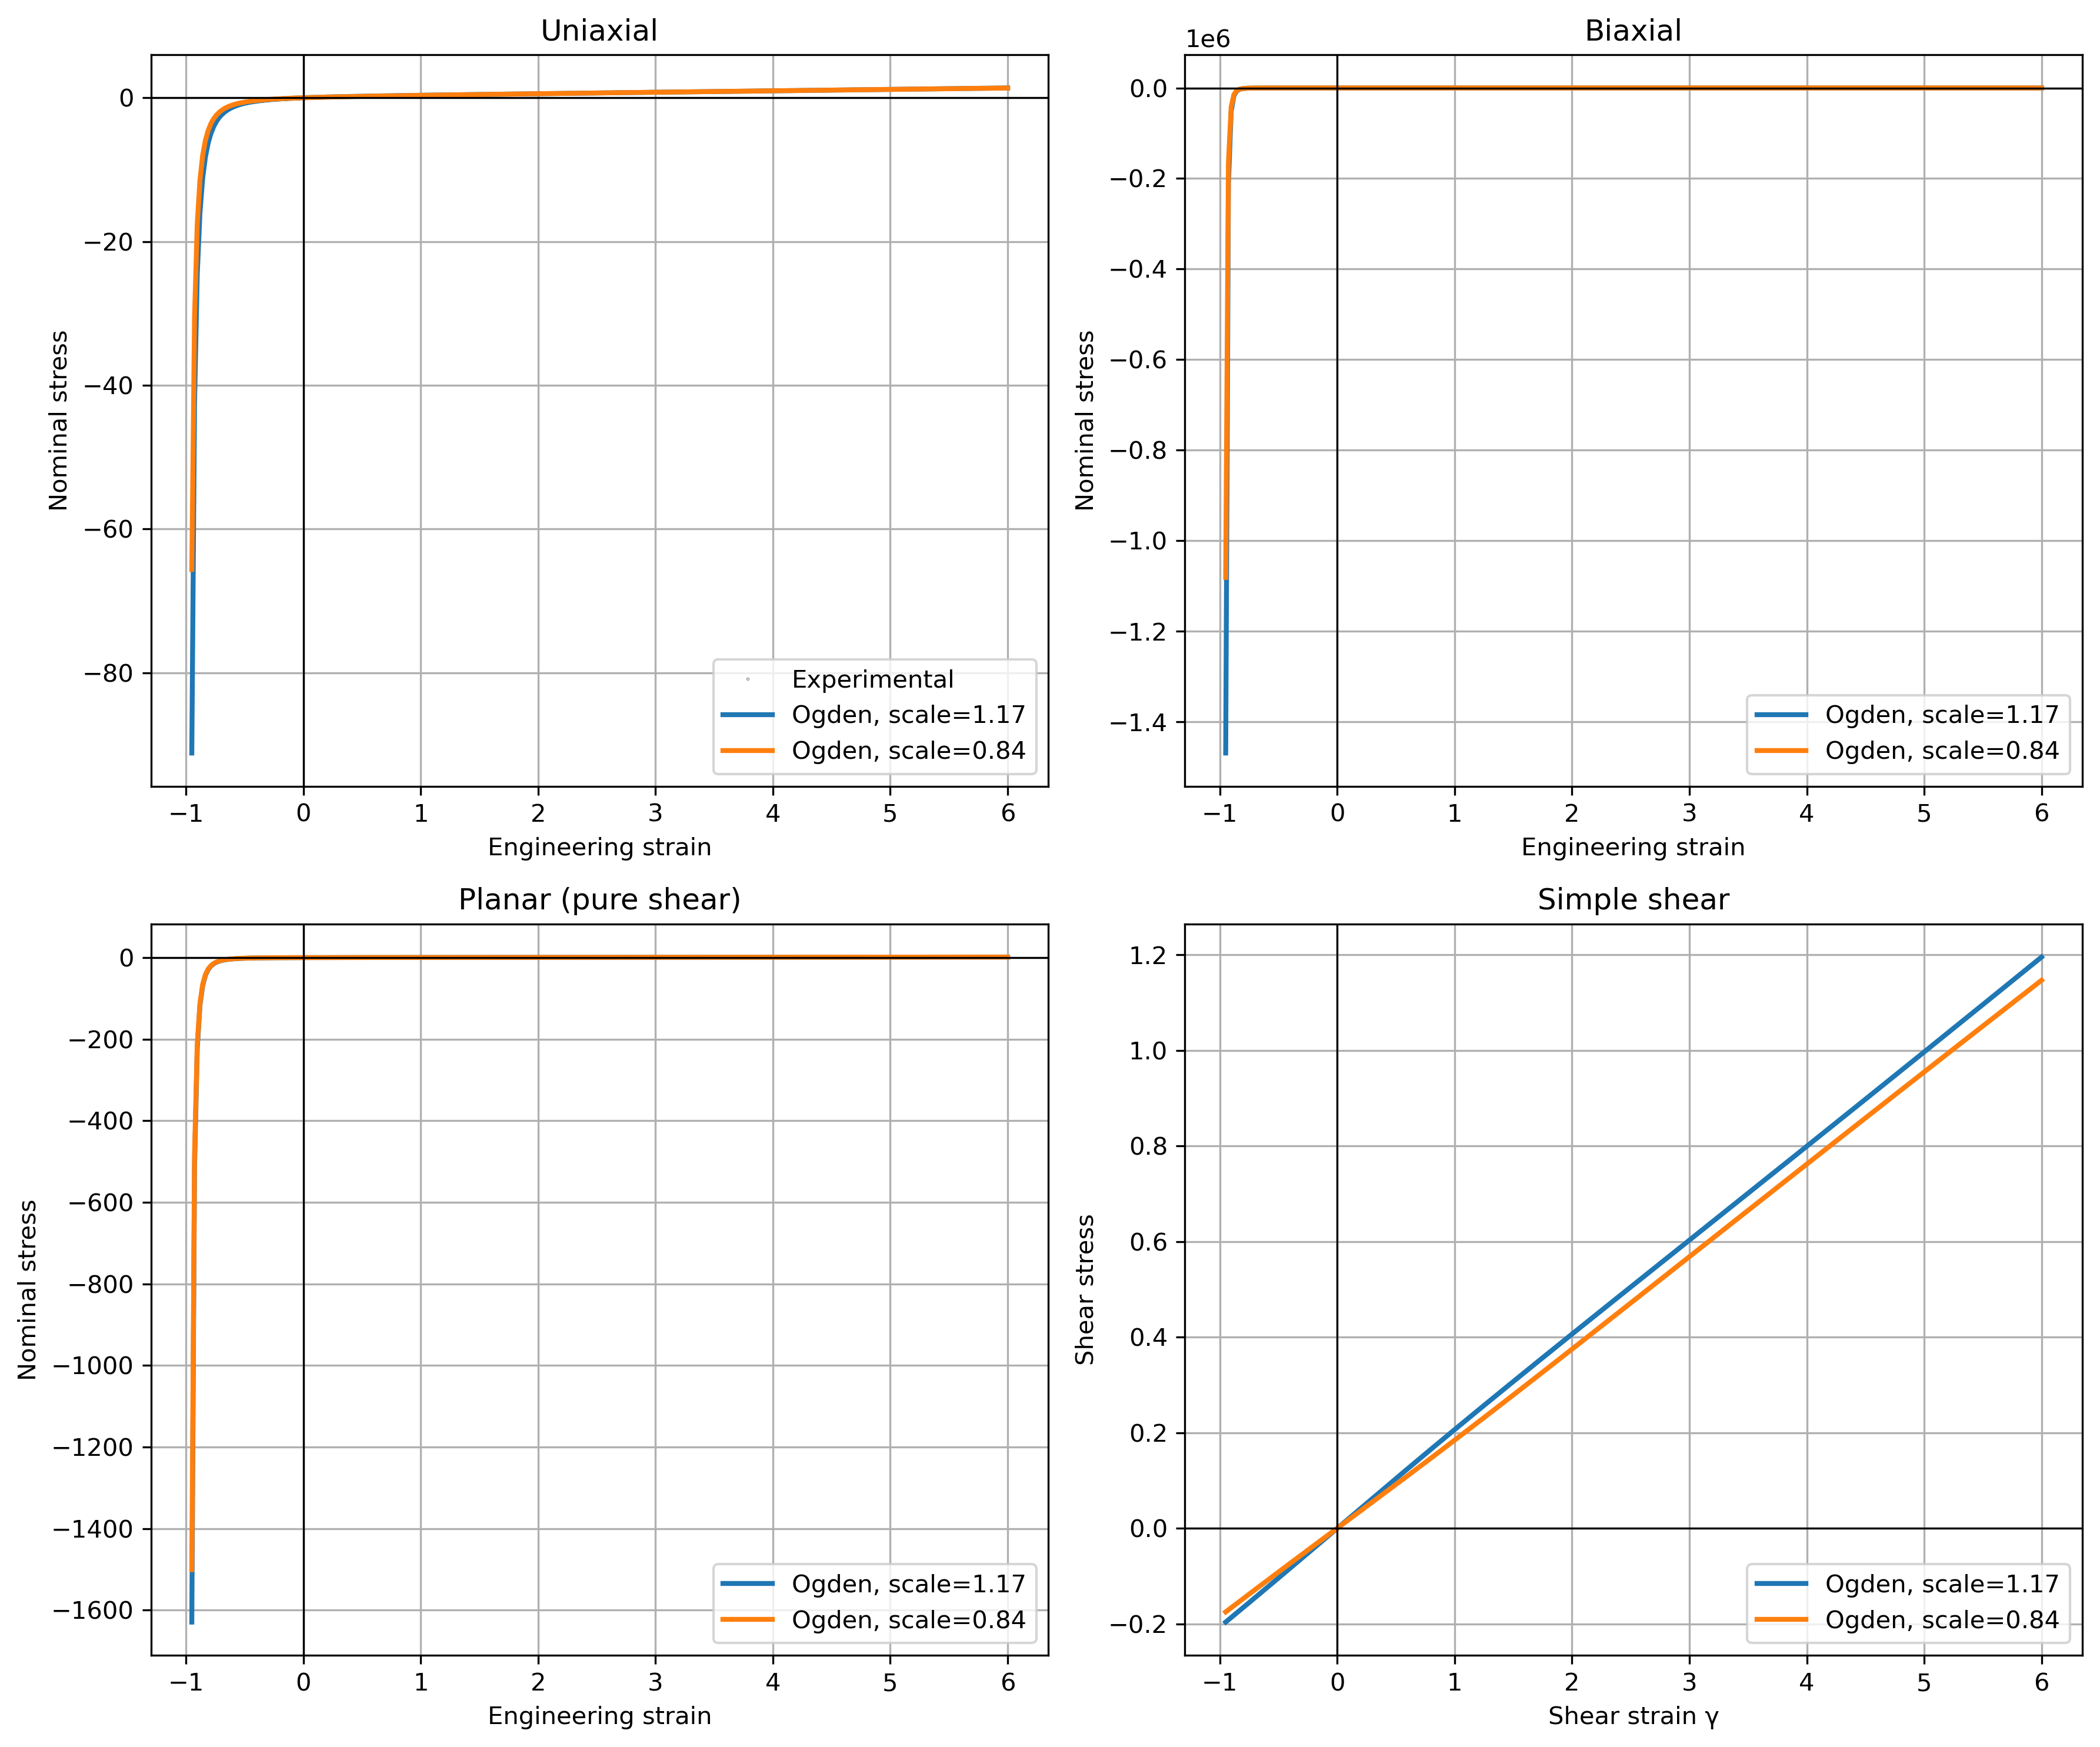

In [24]:
fits_for_plotting_comp = fit_results_to_plot_fits(fit_results_comp)
plot_hyperelastic_fits(
    fits=fits_for_plotting_comp,
    uniaxial_range=(-compression_strain_max, tension_strain_max),
    biaxial_range=(-compression_strain_max, tension_strain_max),
    planar_range=(-compression_strain_max, tension_strain_max),
    shear_range=(-compression_strain_max, tension_strain_max),
    df=df_exp_plot,
)

# TENSION

Input Neo-Hookean C10 = 0.0975
Input Neo-Hookean mu  = 0.195
Synthetic side      = tension

NH compression, scaled NH tension scale=1.22
Initial shear modulus sum(mu_i) = 0.20362962
K = 1.9684196
Ogden parameters:
  mu1 = 0.21504382, alpha1 = 2.0864559, D1 = 1.0160435
  mu2 = -0.011414199, alpha2 = -1.2639109, D2 = 0

NH compression, scaled NH tension scale=0.78
Initial shear modulus sum(mu_i) = 0.18554658
K = 1.7936169
Ogden parameters:
  mu1 = 0.17290015, alpha1 = 1.8865383, D1 = 1.1150653
  mu2 = 0.012646433, alpha2 = -1.2257258, D2 = 0

Ogden curve comparison on non-synthetic side: compression

----------------------------------------------------------------------
Scale 1.22 vs scale 0.78
Max absolute difference = 0.041292549
Percentage difference at max absolute difference = 0.05294481%
  at compression strain = 0.95
  curve 1 stress = 77.971037
  curve 2 stress = 78.01233


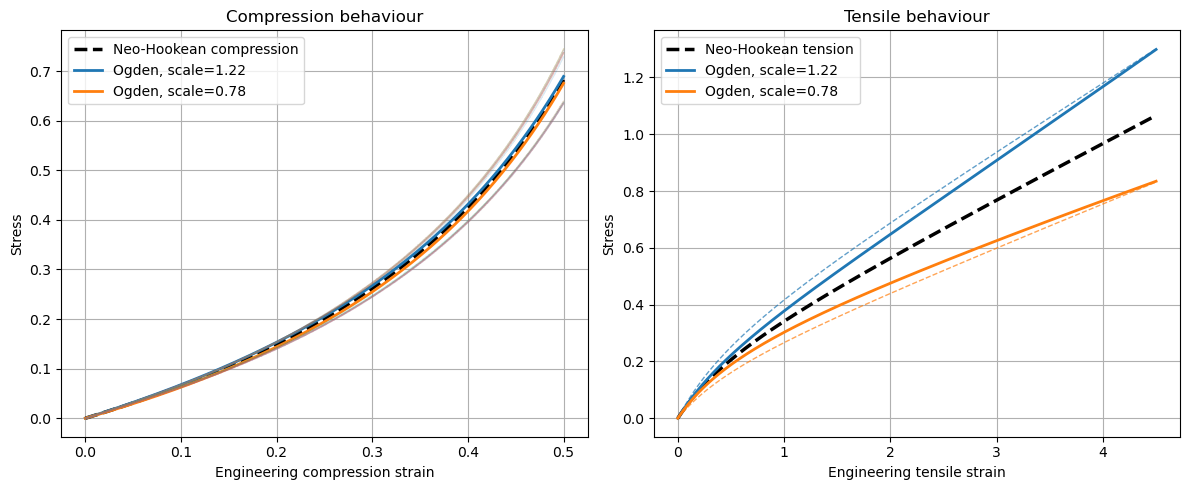

In [25]:

# ============================================================
# USER SETTINGS
# ============================================================

N_OGDEN = 2

n_points = 250
compression_strain_min = 0.00
compression_strain_max = 0.95
tension_strain_max = 6.0


C10_input = 0.0975
synthetic_side = "tension"     # "compression" or "tension"
synthetic_scales = [1.22, 0.78]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = 0.45                 # None for incompressible

fit_results_tens = find_curves(
        N_OGDEN, 
        n_points, 
        compression_strain_min, 
        compression_strain_max, 
        tension_strain_max, 
        C10_input, 
        synthetic_side, 
        synthetic_scales,compression_weight,
        tension_weight,
        poisson_ratio,
        plot_max_comp=0.5,
        plot_max_tens=4.5
    )

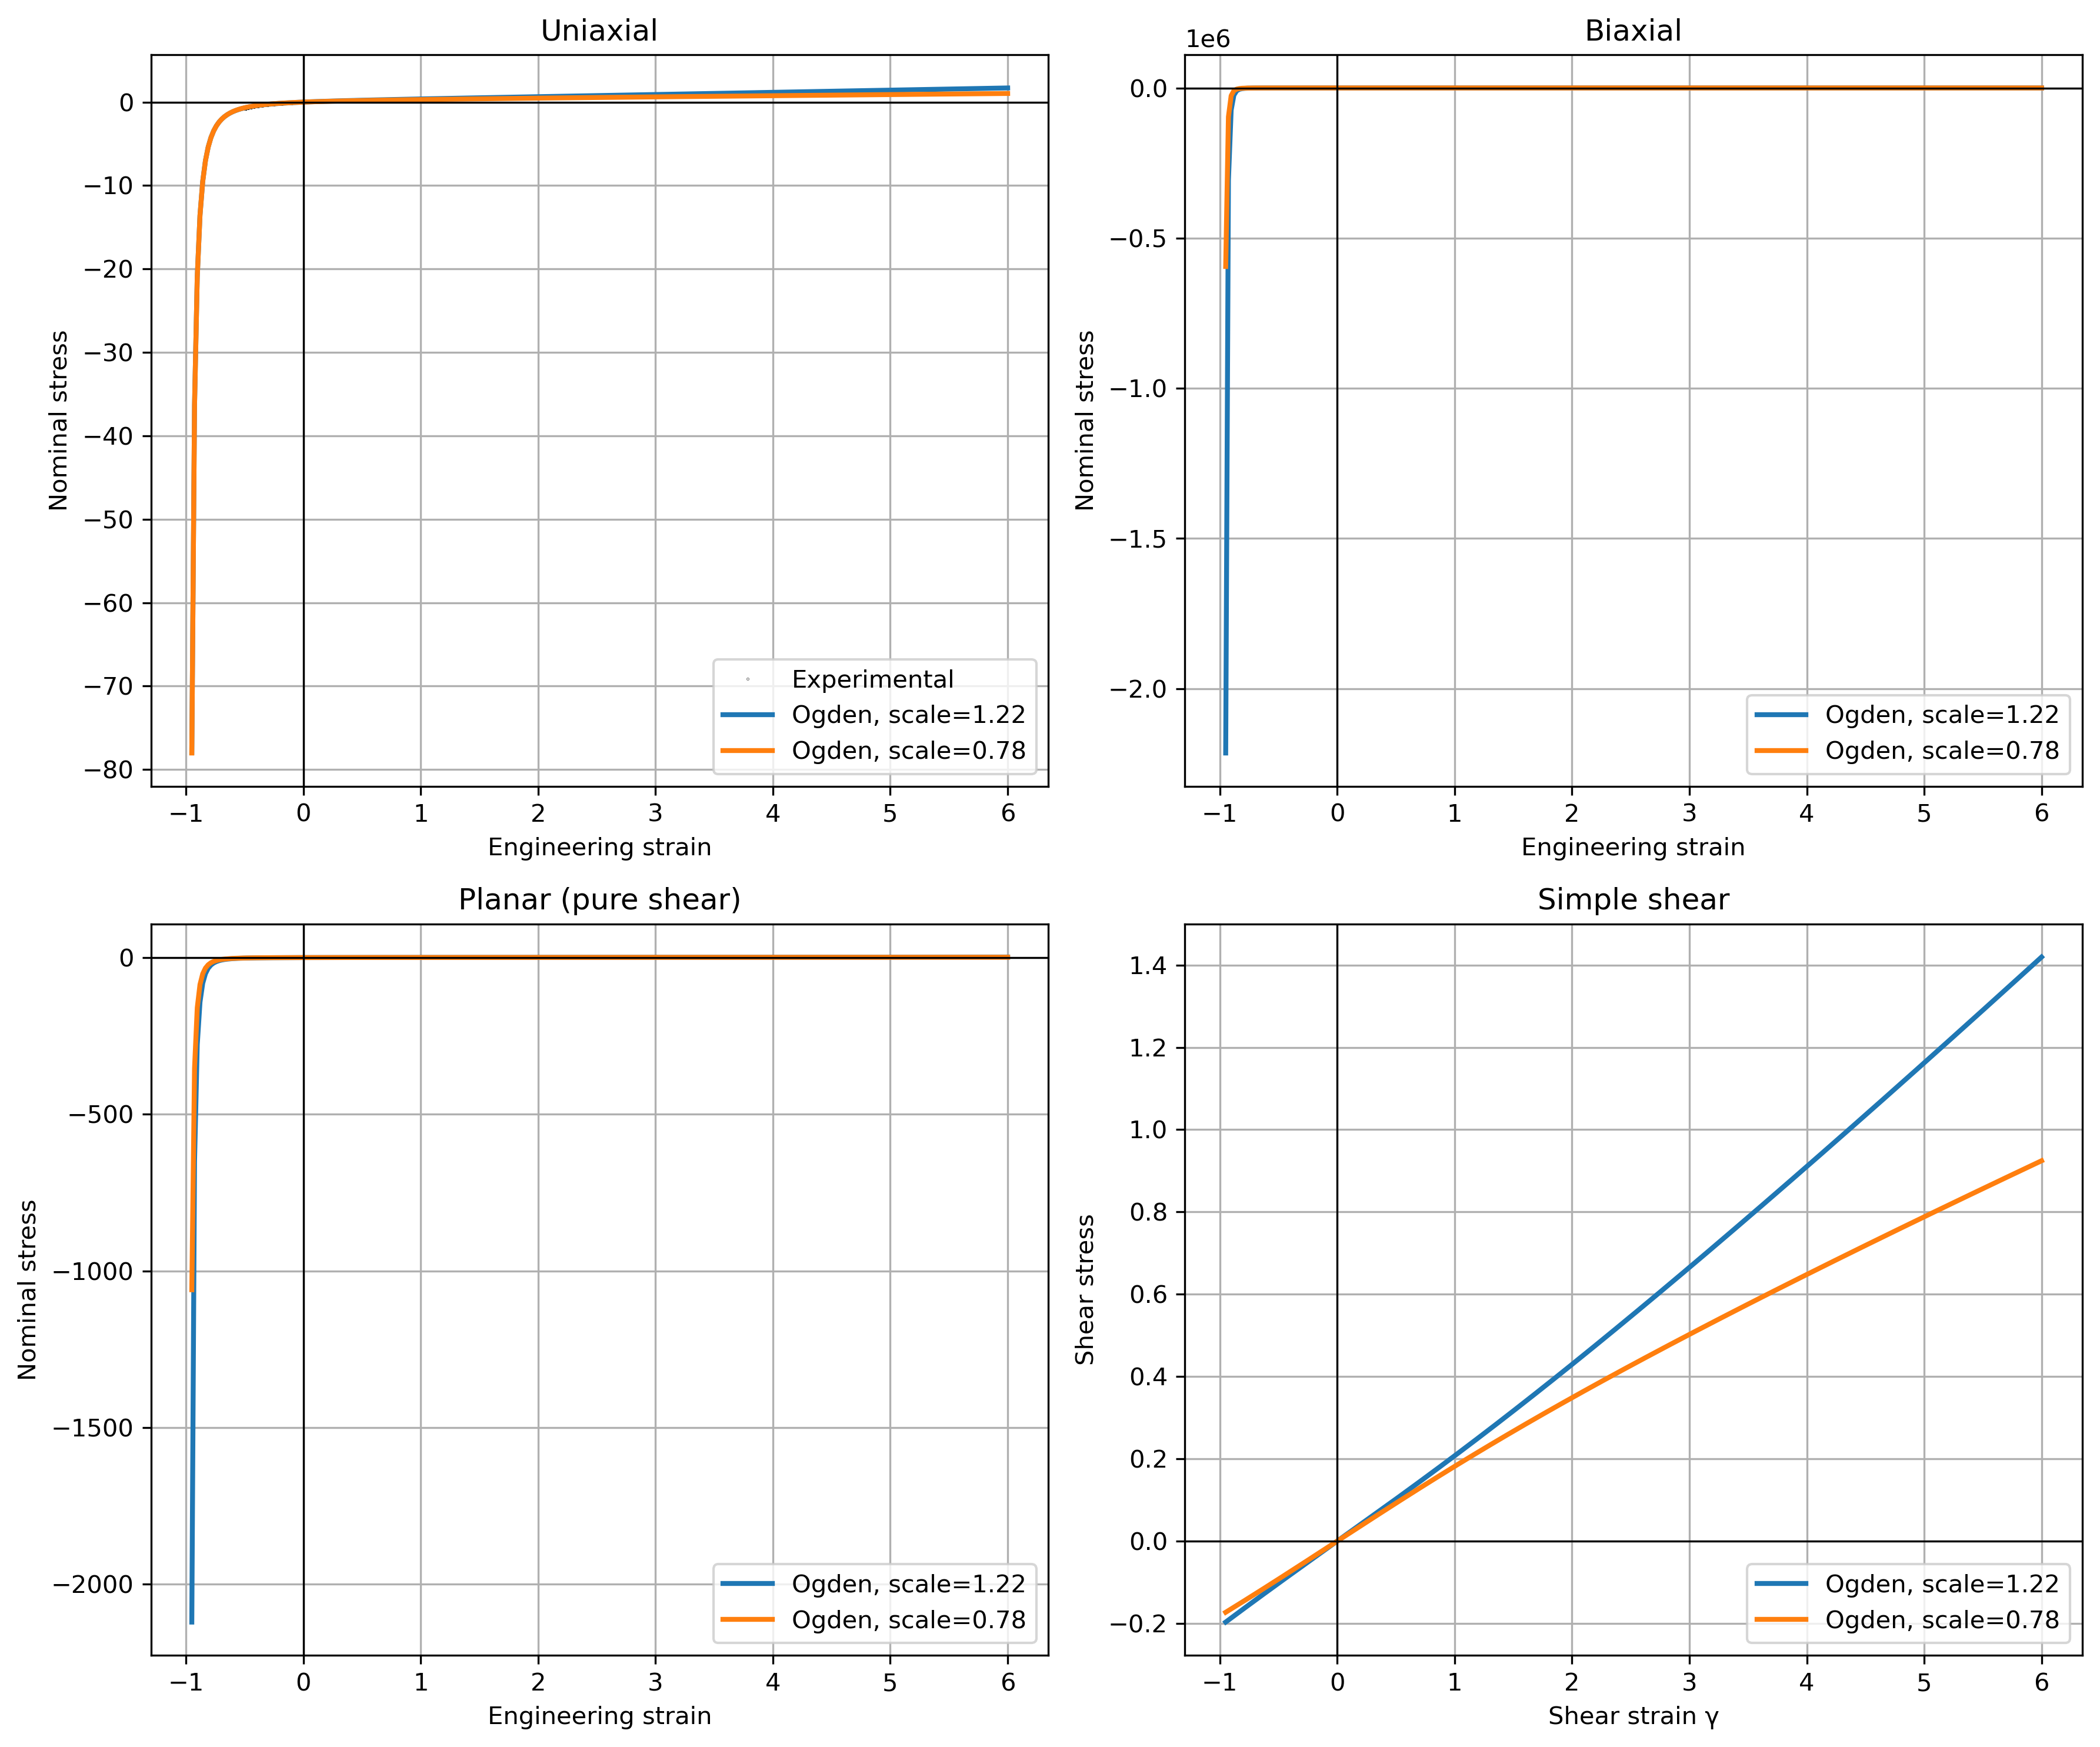

In [26]:
fits_for_plotting_tens = fit_results_to_plot_fits(fit_results_tens)
plot_hyperelastic_fits(
    fits=fits_for_plotting_tens,
    uniaxial_range=(-compression_strain_max, tension_strain_max),
    biaxial_range=(-compression_strain_max, tension_strain_max),
    planar_range=(-compression_strain_max, tension_strain_max),
    shear_range=(-compression_strain_max, tension_strain_max),
    df=df_exp_plot,
)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def ogden_nominal_uniaxial_stress(strain, params):
    """
    strain = engineering strain
    stress = engineering stress
    """
    lam = 1.0 + strain
    P = np.zeros_like(lam, dtype=float)

    for mu, alpha in zip(params[0::2], params[1::2]):
        P += (2.0 * mu / alpha) * (
            lam**(alpha - 1.0)
            - lam**(-alpha / 2.0 - 1.0)
        )

    return P

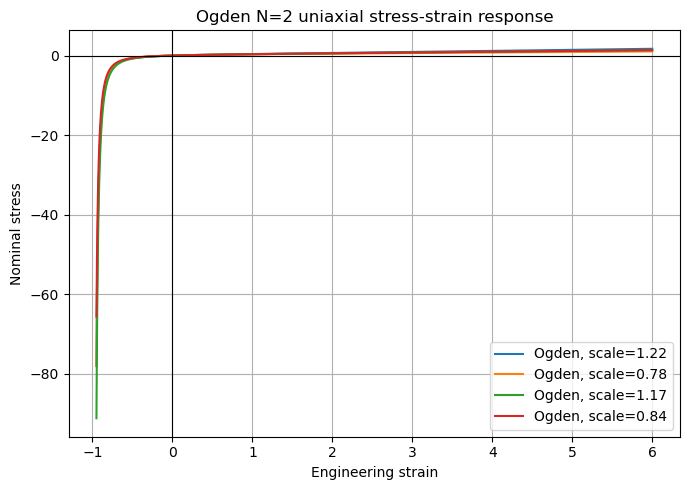

In [34]:
plt.figure(figsize=(7, 5))

strain = np.linspace(-compression_strain_max, tension_strain_max, 1000)
pd.DataFrame({'strain': strain}).to_csv(f'syntheticData/strain.csv', index=False, header=False)

fits = fits_for_plotting_tens
for fit in fits:
    name = 'tens_' + fit['model'].split(',')[-1].split('=')[-1]
    stress = ogden_nominal_uniaxial_stress(strain, fit["params"])
    pd.DataFrame({name: stress}).to_csv(f'syntheticData/{name}.csv', index=False, header=False)

    plt.plot(strain, stress, label=fit["model"])

fits = fits_for_plotting_comp
for fit in fits:
    name = 'comp_' + fit['model'].split(',')[-1].split('=')[-1]
    stress = ogden_nominal_uniaxial_stress(strain, fit["params"])
    pd.DataFrame({name: stress}).to_csv(f'syntheticData/{name}.csv', index=False, header=False)

    plt.plot(strain, stress, label=fit["model"])

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Engineering strain")
plt.ylabel("Nominal stress")
plt.title("Ogden N=2 uniaxial stress-strain response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
fits_for_plotting_comp

[{'model': 'Ogden, scale=1.17',
  'params': array([ 0.18101116,  2.04318667,  0.02741699, -0.83162853]),
  'D': array([0.99265166, 0.        ]),
  'K': np.float64(2.014805465888727),
  'mu_initial': np.float64(0.2084281516436614)},
 {'model': 'Ogden, scale=0.84',
  'params': array([ 0.20839655,  1.96172608, -0.02590992, -0.82933317]),
  'D': array([1.1337628, 0.       ]),
  'K': np.float64(1.764037421609383),
  'mu_initial': np.float64(0.18248662982166028)}]

In [36]:
fits_for_plotting_tens

[{'model': 'Ogden, scale=1.22',
  'params': array([ 0.21504382,  2.0864559 , -0.0114142 , -1.26391085]),
  'D': array([1.01604351, 0.        ]),
  'K': np.float64(1.9684196380969692),
  'mu_initial': np.float64(0.20362961773416918)},
 {'model': 'Ogden, scale=0.78',
  'params': array([ 0.17290015,  1.8865383 ,  0.01264643, -1.22572584]),
  'D': array([1.11506529, 0.        ]),
  'K': np.float64(1.7936169464869929),
  'mu_initial': np.float64(0.1855465806710682)}]